In [1]:
# Imports

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Concatenate, Flatten, Bidirectional, Layer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Visualization
import seaborn as sns

In [2]:
# [Cell 2] - Load Data
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\feature_combined_emotion_dataset.csv"
df = pd.read_csv(data_path)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615486 entries, 0 to 615485
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   text                   615476 non-null  object 
 1   happiness              615486 non-null  int64  
 2   sadness                615486 non-null  int64  
 3   disgust                615486 non-null  int64  
 4   anger                  615486 non-null  int64  
 5   fear                   615486 non-null  int64  
 6   surprise               615486 non-null  int64  
 7   neutral                615486 non-null  int64  
 8   POS_Tags               615486 non-null  object 
 9   TF_IDF                 615486 non-null  object 
 10  TextBlob_Polarity      615486 non-null  float64
 11  TextBlob_Subjectivity  615486 non-null  float64
 12  TextBlob_Sentiment     615486 non-null  object 
 13  VADER_Scores           615486 non-null  object 
 14  VADER_Compound         615486 non-nu

In [4]:
df

,text,happiness,sadness,disgust,anger,fear,surprise,neutral,POS_Tags,TF_IDF,TextBlob_Polarity,TextBlob_Subjectivity,TextBlob_Sentiment,VADER_Scores,VADER_Compound,VADER_Positive,VADER_Neutral,VADER_Negative,TextBlob_Scores
0,that game hurt,0,1,0,0,0,0,0,"[('that', 'DT'), ('game', 'NN'), ('hurt', 'VBD')]",{'that': 1.0},-0.400000,0.400000,Negative,"{'neg': 0.63, 'neu': 0.37, 'pos': 0.0, 'compou...",-0.5267,0.000,0.370,0.630,"{'polarity': -0.4, 'subjectivity': 0.4}"
1,you do right if you do not care then fuck them,0,0,0,0,0,0,1,"[('you', 'PRP'), ('do', 'VBP'), ('right', 'RB'...","{'do': 0.5732251067474712, 'if': 0.31441654565...",-0.057143,0.567857,Negative,"{'neg': 0.182, 'neu': 0.622, 'pos': 0.197, 'co...",0.0572,0.197,0.622,0.182,"{'polarity': -0.05714285714285716, 'subjectivi..."
2,man i love reddit,1,0,0,0,0,0,0,"[('man', 'NN'), ('i', 'VBZ'), ('love', 'VBP'),...",{'love': 1.0},0.500000,0.600000,Positive,"{'neg': 0.0, 'neu': 0.417, 'pos': 0.583, 'comp...",0.6369,0.583,0.417,0.000,"{'polarity': 0.5, 'subjectivity': 0.6}"
3,name was nowhere near them he was by the falcon,0,0,0,0,0,0,1,"[('name', 'NN'), ('was', 'VBD'), ('nowhere', '...","{'by': 0.37931604764418525, 'he': 0.3851894033...",0.100000,0.400000,Positive,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,"{'polarity': 0.1, 'subjectivity': 0.4}"
4,right considering it is such an important docu...,1,0,0,0,0,0,0,"[('right', 'RB'), ('considering', 'VBG'), ('it...","{'an': 0.4324010300727291, 'and': 0.1988694675...",0.221429,0.558929,Positive,"{'neg': 0.093, 'neu': 0.643, 'pos': 0.264, 'co...",0.5859,0.264,0.643,0.093,"{'polarity': 0.22142857142857142, 'subjectivit..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
615481,you or me,0,0,0,0,0,0,1,"[('you', 'PRP'), ('or', 'CC'), ('me', 'PRP')]","{'me': 0.5448537095642766, 'or': 0.64650866016...",0.000000,0.000000,Neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,"{'polarity': 0.0, 'subjectivity': 0.0}"
615482,i got it uh joey women dont have adams apples,0,0,0,0,0,0,1,"[('i', 'NN'), ('got', 'VBD'), ('it', 'PRP'), (...","{'dont': 0.7612941987815495, 'have': 0.4868715...",0.000000,0.000000,Neutral,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,"{'polarity': 0.0, 'subjectivity': 0.0}"
615483,you guys are messing with me right,0,0,0,0,0,1,0,"[('you', 'PRP'), ('guys', 'NNS'), ('are', 'VBP...","{'are': 0.44525587452302323, 'me': 0.394031701...",0.285714,0.535714,Positive,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,1.000,0.000,"{'polarity': 0.2857142857142857, 'subjectivity..."
615484,yeah,0,0,0,0,0,0,1,"[('yeah', 'NN')]",{},0.000000,0.000000,Neutral,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,1.000,0.000,0.000,"{'polarity': 0.0, 'subjectivity': 0.0}"


___

In [6]:
# 1. Check GPU availability

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow version:", tf.__version__)
print("GPU Device:", tf.test.gpu_device_name())

# 2. Configure GPU memory growth (prevents memory errors)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU memory growth enabled')
    except RuntimeError as e:
        print(e)

Num GPUs Available:  1
TensorFlow version: 2.10.1
GPU Device: /device:GPU:0
GPU memory growth enabled


___

In [9]:
# PARAMETERS
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\feature_combined_emotion_dataset.csv"
glove_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\glove.6B.300d.txt"
max_words = 10000
max_len = 100
embedding_dim = 300

In [10]:
# LOAD DATA
df = pd.read_csv(data_path)

In [11]:
# Create target label by taking argmax across emotion columns
emotion_cols = ['happiness', 'sadness', 'disgust', 'anger', 'fear', 'surprise', 'neutral']
df['label'] = df[emotion_cols].values.argmax(axis=1)
num_classes = len(emotion_cols)
y = to_categorical(df['label'], num_classes=num_classes)

In [12]:
# Prepare sentiment features (e.g., TextBlob_Polarity and VADER_Compound)
sentiment_features = df[['TextBlob_Polarity', 'VADER_Compound']].values
# Optionally, normalize these features if necessary

scaler = StandardScaler()
sentiment_features = scaler.fit_transform(sentiment_features)

# TOKENIZE TEXT
df['text'] = df['text'].astype(str)

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
X_text = pad_sequences(sequences, maxlen=max_len)

In [13]:
# Add this after your tokenizer.fit_on_texts()
print("Total unique words:", len(tokenizer.word_index))
print("Max word index:", max(tokenizer.word_index.values()))
if hasattr(tokenizer, 'num_words'):
    print("max_words limit:", tokenizer.num_words)

Total unique words: 93611
Max word index: 93611
max_words limit: 10000


In [14]:
# Check coverage (add this code to verify we're not losing too much information)
word_counts = pd.Series(sum(tokenizer.word_counts.values()))
top_words = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)[:max_words]
coverage = sum(count for word, count in top_words) / word_counts.sum()
print(f"Vocabulary coverage with {max_words} words: {coverage:.2%}")

Vocabulary coverage with 10000 words: 96.69%


In [15]:
# SPLIT DATA (70% train, 20% val, 10% test)
X_text_temp, X_text_test, X_sent_temp, X_sent_test, y_temp, y_test = train_test_split(
    X_text, sentiment_features, y, test_size=0.10, random_state=42, stratify=y)

X_text_train, X_text_val, X_sent_train, X_sent_val, y_train, y_val = train_test_split(
    X_text_temp, X_sent_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp)


In [16]:
# LOAD PRETRAINED GLOVE EMBEDDINGS
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coeffs
print(f'Found {len(embeddings_index)} word vectors in GloVe.')

Found 400000 word vectors in GloVe.


In [17]:
# CREATE EMBEDDING MATRIX
word_index = tokenizer.word_index
num_words = min(max_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= max_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [19]:
# MODEL DEFINITION (Functional API)
text_input = Input(shape=(max_len,), name='text_input')
embedding_layer = Embedding(input_dim=num_words,
                          output_dim=embedding_dim,
                          weights=[embedding_matrix],
                          input_length=max_len,
                          trainable=False)(text_input)

# Modified LSTM configuration for GPU optimization
lstm_out = Bidirectional(LSTM(128, 
                             dropout=0.2,
                             # Remove recurrent_dropout for cuDNN compatibility
                             return_sequences=False,
                             unroll=False,  # Keep False for GPU
                             use_bias=True))(embedding_layer)

# Rest of the model remains the same
sent_input = Input(shape=(sentiment_features.shape[1],), name='sentiment_input')
sent_dense = Dense(32, activation='relu')(sent_input)
sent_dense = Dropout(0.3)(sent_dense)

# Combine both branches
combined = Concatenate()([lstm_out, sent_dense])
combined_dense = Dense(64, activation='relu')(combined)
combined_dense = Dropout(0.5)(combined_dense)
output = Dense(num_classes, activation='softmax')(combined_dense)

# Build and compile the model
model = Model(inputs=[text_input, sent_input], outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001),
             loss='categorical_crossentropy',
             metrics=['accuracy'])

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 sentiment_input (InputLayer)   [(None, 2)]          0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 100, 300)     3000000     ['text_input[0][0]']             
                                                                                                  
 dense_3 (Dense)                (None, 32)           96          ['sentiment_input[0][0]']        
                                                                                            

In [20]:
# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [21]:
# TRAIN THE MODEL with callbacks
history = model.fit(
    {'text_input': X_text_train, 'sentiment_input': X_sent_train},
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=({'text_input': X_text_val, 'sentiment_input': X_sent_val}, y_val),
    callbacks=callbacks
)

# EVALUATE ON TEST SET
loss, acc = model.evaluate({'text_input': X_text_test, 'sentiment_input': X_sent_test}, y_test)
print(f'Test Loss: {loss:.4f} / Test Accuracy: {acc:.4f}')


Epoch 1/50
13465/13465 [==============================] - 438s 32ms/step - loss: 0.5716 - accuracy: 0.7859 - val_loss: 0.4539 - val_accuracy: 0.8188 - lr: 0.0010
Epoch 2/50
13465/13465 [==============================] - 442s 33ms/step - loss: 0.4647 - accuracy: 0.8176 - val_loss: 0.4403 - val_accuracy: 0.8236 - lr: 0.0010
Epoch 3/50
13465/13465 [==============================] - 438s 33ms/step - loss: 0.4498 - accuracy: 0.8221 - val_loss: 0.4363 - val_accuracy: 0.8245 - lr: 0.0010
Epoch 4/50
13465/13465 [==============================] - 322s 24ms/step - loss: 0.4416 - accuracy: 0.8242 - val_loss: 0.4330 - val_accuracy: 0.8254 - lr: 0.0010
Epoch 5/50
13465/13465 [==============================] - 321s 24ms/step - loss: 0.4351 - accuracy: 0.8264 - val_loss: 0.4326 - val_accuracy: 0.8258 - lr: 0.0010
Epoch 6/50
13465/13465 [==============================] - 384s 29ms/step - loss: 0.4309 - accuracy: 0.8272 - val_loss: 0.4338 - val_accuracy: 0.8255 - lr: 0.0010
Epoch 7/50
13465/13465 [====

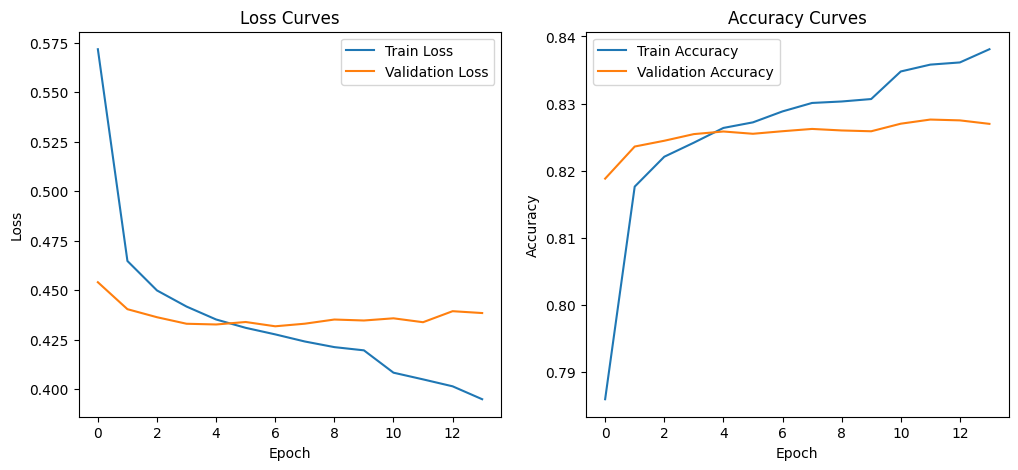

In [22]:
# Plot Loss Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [23]:
# [Cell 8] - Save Model
model.save("lstm_model_7.h5")

In [24]:
# Generate predictions on the test set
y_pred = model.predict({'text_input': X_text_test, 'sentiment_input': X_sent_test})
# Convert predictions from probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
# Convert one-hot encoded true labels to class labels
y_true = np.argmax(y_test, axis=1)

1924/1924 [==============================] - 17s 9ms/step


In [25]:
# Calculate metrics (using weighted average for multi-class)
accuracy = accuracy_score(y_true, y_pred_classes)
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

In [26]:
# Print overall metrics
print("\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Overall Metrics:
Accuracy: 0.8286
Precision: 0.8558
Recall: 0.8286
F1 Score: 0.8328


In [27]:
# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     24816
           1       0.95      0.92      0.93     13312
           2       0.48      0.12      0.19       322
           3       0.85      0.71      0.78      8225
           4       0.86      0.89      0.87      5200
           5       0.83      0.39      0.53      2964
           6       0.46      0.77      0.58      6710

    accuracy                           0.83     61549
   macro avg       0.76      0.67      0.68     61549
weighted avg       0.86      0.83      0.83     61549



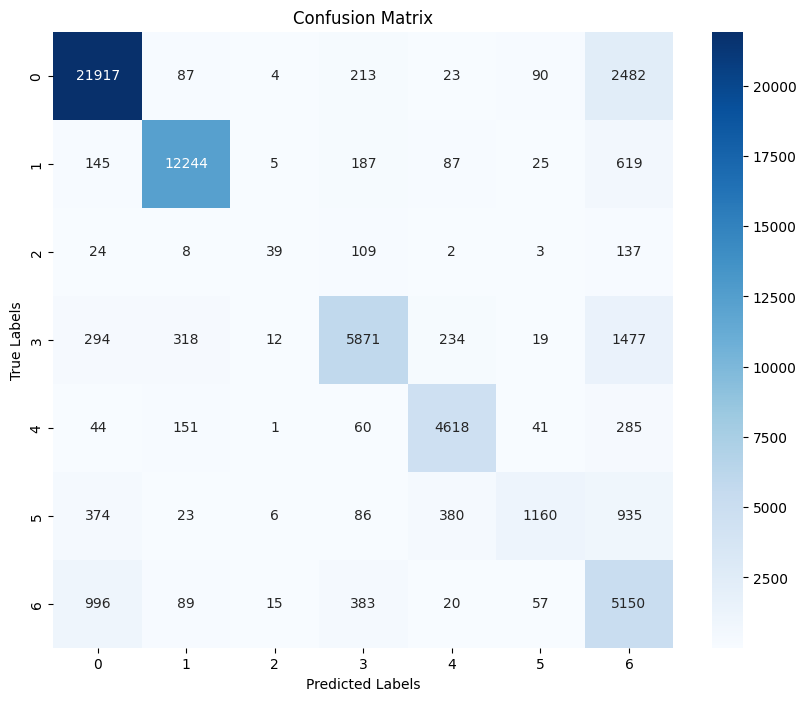

In [28]:
# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [29]:
# Get predictions using both text and sentiment features
y_score = model.predict({'text_input': X_text_test, 'sentiment_input': X_sent_test})
n_classes = y_test.shape[1]


1924/1924 [==============================] - 17s 9ms/step


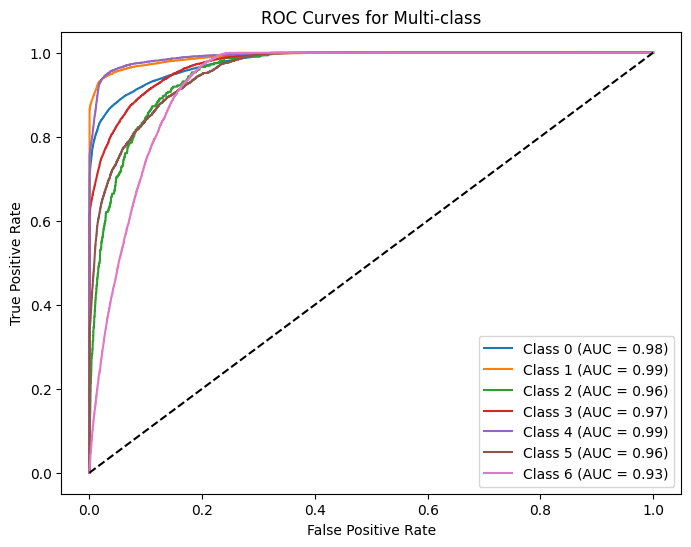

In [30]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-class')
plt.legend()
plt.show()


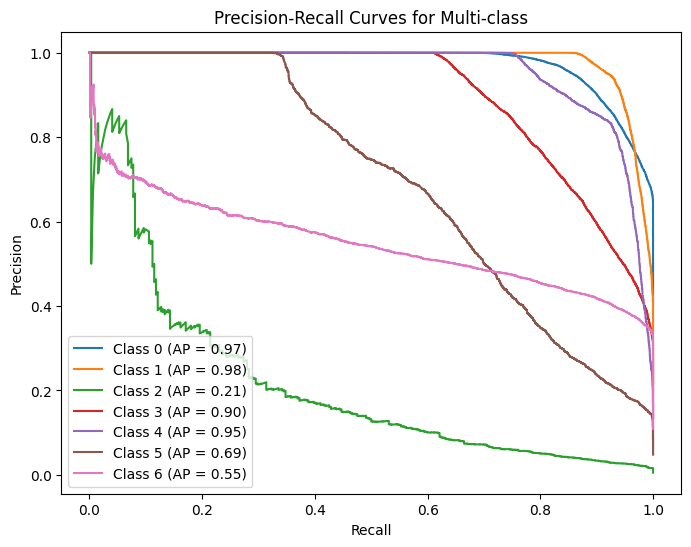

In [31]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision = dict()
recall = dict()
avg_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[:, i])
    avg_precision[i] = average_precision_score(y_test[:, i], y_score[:, i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'Class {i} (AP = {avg_precision[i]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Multi-class')
plt.legend()
plt.show()


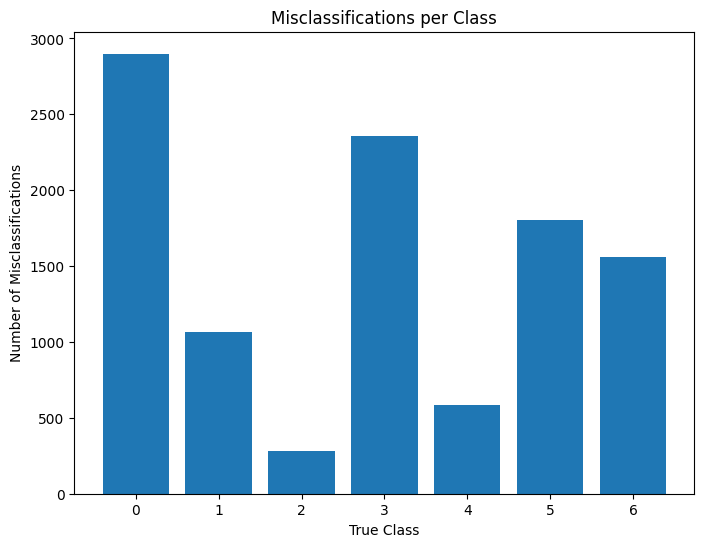

In [32]:
import numpy as np
import matplotlib.pyplot as plt

misclassified = y_true != y_pred_classes
misclass_counts = {}
for true, pred in zip(y_true, y_pred_classes):
    if true != pred:
        misclass_counts[true] = misclass_counts.get(true, 0) + 1

classes = list(misclass_counts.keys())
counts = [misclass_counts[c] for c in classes]

plt.figure(figsize=(8, 6))
plt.bar(classes, counts)
plt.xlabel('True Class')
plt.ylabel('Number of Misclassifications')
plt.title('Misclassifications per Class')
plt.show()


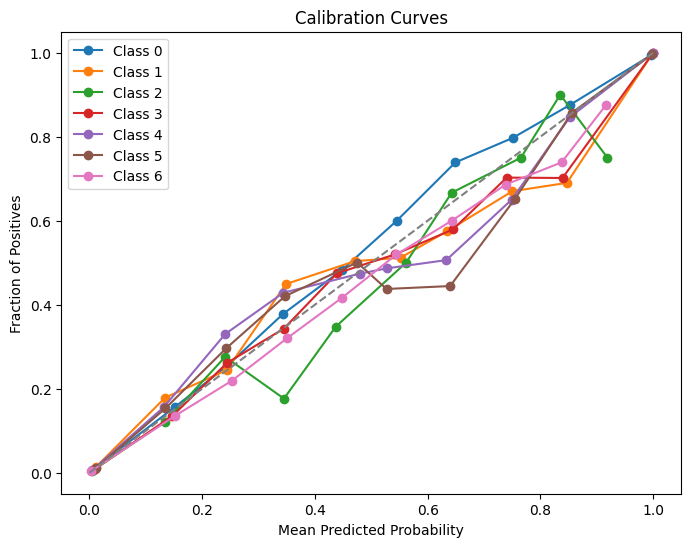

In [33]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    prob_true, prob_pred = calibration_curve(y_test[:, i], y_score[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f'Class {i}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curves')
plt.legend()
plt.show()
